In [2]:
from OOP_so_far import RunSSA, ModuleProperties, CombiningModules, plot_combined_conductance
from sympy import *
import numpy as np
import time

/Users/willalston/Desktop/Msci_Project/git_repos/students/Will/Gillespie_simulations/OOP_so_far.py:1383: SyntaxWarning: invalid escape sequence '\m'
  chem_pot = symbols(f"\mu_{species_symbol}")


In [19]:
SM2

⎡-1  0   1   0   0 ⎤
⎢                  ⎥
⎢1   -1  0   -1  0 ⎥
⎢                  ⎥
⎢0   1   -1  0   1 ⎥
⎢                  ⎥
⎢0   0   0   1   -1⎥
⎢                  ⎥
⎢0   0   0   -1  0 ⎥
⎢                  ⎥
⎢0   0   0   0   1 ⎥
⎢                  ⎥
⎢-1  0   0   0   0 ⎥
⎢                  ⎥
⎣0   0   1   0   0 ⎦

In [15]:
# MODULE 1


SM = Matrix( [[-1,1,0], [1,-1,-1], [0,0,1], [-1,0,-1], [0,1,0]])

species_names = ["Ea", "EaS","EaS2","S","Na"]

num_internal_species = 3


# MODULE 2

SM2 = Matrix([[-1, 0, 1, 0, 0], # first row of internal
                           [1, -1, 0, -1, 0], 
                           [0, 1, -1, 0, 1], 
                           [0, 0, 0, 1, -1],
                             [0, 0, 0, -1, 0], # first row external 
                             [0, 0, 0, 0, 1],
                             [-1, 0, 0, 0, 0],
                             [0, 0, 1, 0, 0]])


species_names2 = ["Eb", "EbF", "EbW", "Eb*", "Na", "Nb", "F", "W"]

num_internal_species2 = 4

# Use ModuleProperties to create module variables for our CRNs




# Define the initial conditions we need to simulate our CRNs using the SSA

simulation_length = 800.0

burn_in_time = 200.0 # This quantity is important for ensuring we are sampling the steady state - it is best to first pick any value
                     # burn_in_time < simulation_length, visually see where the transient state ends on the counts plot, and then
                     # adjust this value appropriately for sampling runs.

initial_counts = [350, 350, 350, 50, 50]
# initial counts for numerical comparison: Na =  66.81977526898818
# initial_counts = [350, 350, 350, 50, 66.81977526898818]


rates = 0.1 * np.array([0.005, 0.8, 0.6, 0.002, 0.012, 0.5])


# initial counts for numerical comparison: Na =  66.81977526898818
initial_counts2 = [350, 350, 350, 350, 50, 50, 50, 50]
# initial_counts2 = [350, 350, 350, 350, 66.81977526898818, 50, 50, 50]

rates2 = 0.1 * np.array([0.01, 1.0, 1.0, 0.5, 1.5, 0.01, 0.01, 1.0, 1.2, 0.01])


# First, create the following module variables for the two CRNs we want to combine.

module1_for_simulating = ModuleProperties(SM, 3, species_names)

module2_for_simulating = ModuleProperties(SM2, 4, species_names2)

# We must create the individual resistance matrices for each module before combining them

module1_for_simulating.calculate_fundamental_resistance_matrix() 

module2_for_simulating.calculate_fundamental_resistance_matrix()

# Then prepare the module variables for simulation

SIM1 = RunSSA(module1_for_simulating, initial_counts, rates, simulation_length, burn_in_time)

SIM2 = RunSSA(module2_for_simulating, initial_counts2, rates2, simulation_length, burn_in_time)




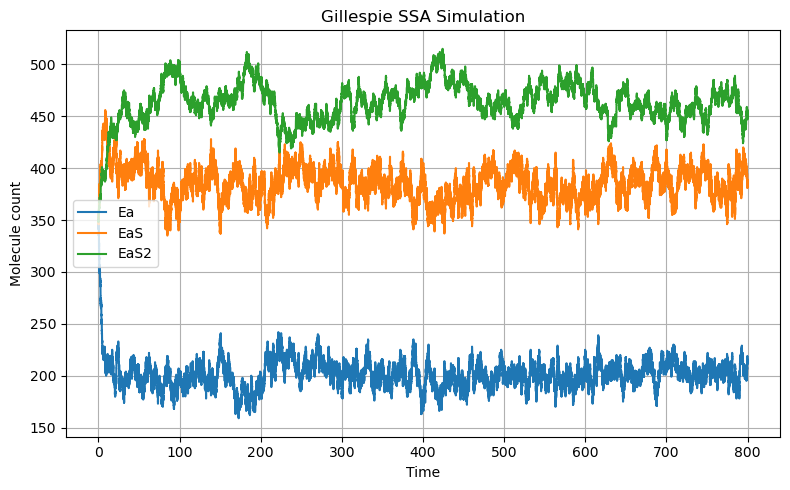

In [9]:
SIM1.run_SSA_and_plot_counts(True)

In [21]:
# Compute data that will be combined. 



# Module 1

SIM1.run_IF_sweep(

        species_index=[3,4],
        count_values=[np.linspace(50,500,50,dtype='int'), Na_SS],
        total_iterations=25, 
        covariance_reaction_indices=[0],   
        verbose=True)

# Module 2

SIM2.run_IF_sweep(

        species_index=[4,5],
        count_values=[Na_SS, np.linspace(50,500,50,dtype='int')],
        total_iterations=25, 
        covariance_reaction_indices=[2,4],   
        verbose=True)

NameError: name 'Na_SS' is not defined

In [20]:


# Compute lists of the numerical conductance for each module, we will not overlay any analytical results.

module1_conductances, _ = SIM1.compute_conductances(analytical_currents=None, analytical_forces=None)

module2_conductances, _ = SIM2.compute_conductances(analytical_currents=None, analytical_forces=None)

# Now we use the CombiningModules class to combine the data from the two modules, this essentially involves replacing the symbolic
# values of resistance with the numerical results calculated above, and the same code as the symbolic case follows.

module3 = CombiningModules(module1_for_simulating, module2_for_simulating, module1_conductances, module2_conductances)

# Store the numerical combined condictance matrices

combined_Gs = module3.numerical_combined_fundamental_CMs# Acquire the serially combined conductance matrices

analytical_G_np = np.array(combined_Gs, dtype=float)
eigenvalues = np.array([np.linalg.eigvals(analytical_G_np[i]) 
                            for i in range(analytical_G_np.shape[0])])

eigenvalues


RuntimeError: No sweep data found. Call run_IF_sweep() first.

In [54]:
m3 = CombiningModules(module1_for_simulating,module2_for_simulating,left_mod_numerical_CM=None,right_mod_numerical_CM=None) # order matters! Require Left feeds into Right

module3_for_simulating = ModuleProperties(m3.stoich_matrix, m3.num_internal_species, m3.species_names)

# Create combined rates and counts

combined_initial_counts, combined_rates = m3.build_combined_initial_counts_and_rates(
    left_initial_counts  = initial_counts,
    right_initial_counts = initial_counts2,
    left_rates = rates,
    right_rates = rates2
)

SIM3 = RunSSA(module3_for_simulating, combined_initial_counts, combined_rates, 800 , 200)


=== Overlapping species detected ===
  ['Na', 'F']
These species appear in both modules and are now internal.
Please enter a single initial count for each:

  Species 'Na':
    Left  module value : 50
    Right module value : 50
  Species 'F':
    Right module value : 50

=== Combined initial counts ===
  [0] Ea           : 350
  [1] EaS          : 350
  [2] EaS2         : 350
  [3] F            : 50.0 ← user entered
  [4] Na           : 50.0 ← user entered
  [5] Eb           : 350
  [6] EbF          : 350
  [7] EbW          : 350
  [8] Eb*          : 350
  [9] S            : 500
  [10] Nb           : 500
  [11] W            : 50

=== Combined rates ===
  Reaction  1 (left ) : k+ = 0.0005,  k- = 0.08
  Reaction  2 (left ) : k+ = 0.06,  k- = 0.0002
  Reaction  3 (left ) : k+ = 0.0012,  k- = 0.05
  Reaction  4 (right) : k+ = 0.001,  k- = 0.1
  Reaction  5 (right) : k+ = 0.1,  k- = 0.05
  Reaction  6 (right) : k+ = 0.15,  k- = 0.001
  Reaction  7 (right) : k+ = 0.001,  k- = 0.1
  Reactio

In [5]:
varying_vals = np.linspace(50,500,50,dtype=int) # values of S and Nb

Na_means = []

for value in varying_vals:

    SIM3.run_SSA_and_plot_counts(True, [350, 350, 350, 350, 350, 350, 350, 350, value, value, 50, 50])

    na_index = SIM3.species_names.index("Na")

    burn_mask = SIM3.time_history >= SIM3.burn_in
    na_mean = np.mean(SIM3.pop_history[burn_mask, na_index])

    Na_means.append(na_mean)
    print("Steady-state Na:", na_mean)


Steady-state Na: 66.14216267112418
Steady-state Na: 80.83227446637133
Steady-state Na: 92.56031278473873
Steady-state Na: 101.61181160807234
Steady-state Na: 112.314887632779
Steady-state Na: 121.28894097971275
Steady-state Na: 133.93613301736528
Steady-state Na: 141.85758074827368
Steady-state Na: 155.02041237624172
Steady-state Na: 164.04426803069055
Steady-state Na: 176.33737442040186
Steady-state Na: 191.3450012681102
Steady-state Na: 197.05821162665916
Steady-state Na: 198.4652035177835
Steady-state Na: 211.23975609662088
Steady-state Na: 226.9785104167064
Steady-state Na: 231.79546899751287
Steady-state Na: 241.11463508970277
Steady-state Na: 252.3437781860698
Steady-state Na: 259.02058676507346
Steady-state Na: 271.71590342594106
Steady-state Na: 285.87725631768956
Steady-state Na: 293.4800521503021
Steady-state Na: 309.44353405760717
Steady-state Na: 311.3330597545574
Steady-state Na: 322.29109527642925
Steady-state Na: 335.0433888689483
Steady-state Na: 340.8596106903674
Stead

Sweep 1/50  ([S] = 50, [Nb] = 50)
Sweep 2/50  ([S] = 59, [Nb] = 59)
Sweep 3/50  ([S] = 68, [Nb] = 68)
Sweep 4/50  ([S] = 77, [Nb] = 77)
Sweep 5/50  ([S] = 86, [Nb] = 86)
Sweep 6/50  ([S] = 95, [Nb] = 95)
Sweep 7/50  ([S] = 105, [Nb] = 105)
Sweep 8/50  ([S] = 114, [Nb] = 114)
Sweep 9/50  ([S] = 123, [Nb] = 123)
Sweep 10/50  ([S] = 132, [Nb] = 132)
Sweep 11/50  ([S] = 141, [Nb] = 141)
Sweep 12/50  ([S] = 151, [Nb] = 151)
Sweep 13/50  ([S] = 160, [Nb] = 160)
Sweep 14/50  ([S] = 169, [Nb] = 169)
Sweep 15/50  ([S] = 178, [Nb] = 178)
Sweep 16/50  ([S] = 187, [Nb] = 187)
Sweep 17/50  ([S] = 196, [Nb] = 196)
Sweep 18/50  ([S] = 206, [Nb] = 206)
Sweep 19/50  ([S] = 215, [Nb] = 215)
Sweep 20/50  ([S] = 224, [Nb] = 224)
Sweep 21/50  ([S] = 233, [Nb] = 233)
Sweep 22/50  ([S] = 242, [Nb] = 242)
Sweep 23/50  ([S] = 252, [Nb] = 252)
Sweep 24/50  ([S] = 261, [Nb] = 261)
Sweep 25/50  ([S] = 270, [Nb] = 270)
Sweep 26/50  ([S] = 279, [Nb] = 279)
Sweep 27/50  ([S] = 288, [Nb] = 288)
Sweep 28/50  ([S] = 29

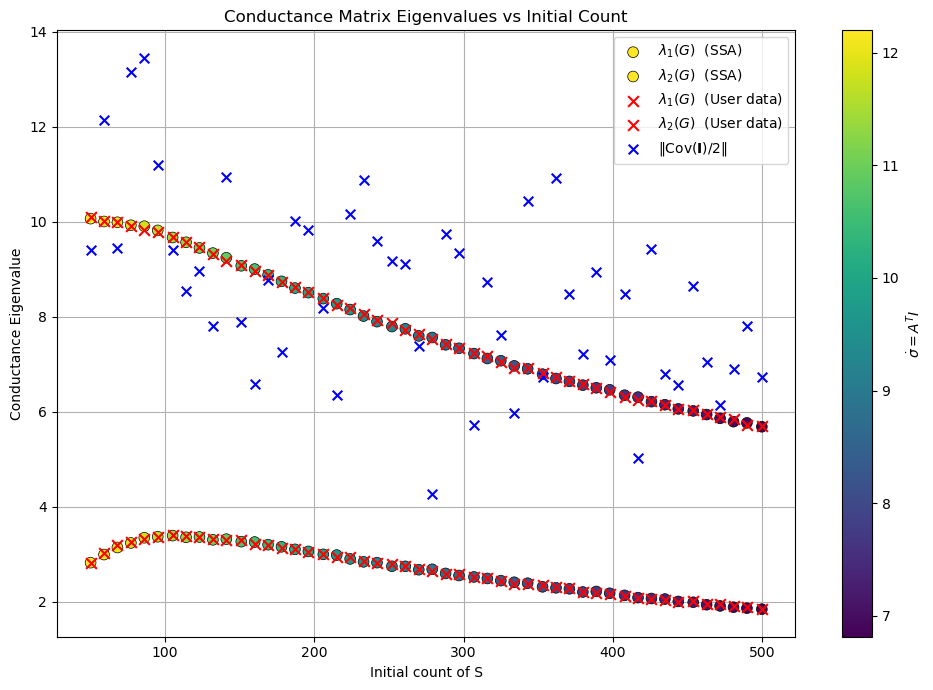

In [11]:
# And again run the sim over many values of a specified species to see the conductance changes (let's try 'S' and 'Nb', as these
# are external species. This is indexes = 8,9 (varying over the same quantity). And lets ignore covariance for now.

# Run the sweep

SIM3.run_IF_sweep(
    
        species_index=[8,9],
        count_values=[np.linspace(50,500,50,dtype='int'),np.linspace(50,500,50,dtype='int')],
        total_iterations=50, 
        covariance_reaction_indices=[5,7],   
        verbose=True)


# Compute the conductance and plot.

SIM3.compute_conductances(analytical_currents=None, analytical_forces=None)

SIM3.plot_conductance(
        analytical_G=eigenvalues,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=False
    )

# Trying to do it without simulating the joimnt module first to find the Na

In [ ]:
# import numpy as np


# from scipy.optimize import brentq

# def calculate_steady_state_overlap_counts(species_indexes_mod1, mod1_species_counts, species_indexes_mod2,mod2_species_counts):
    

#     # ─────────────────────────────────────────────
#     # STEP 1: Low-level flux computation
#     # ─────────────────────────────────────────────

#     def compute_species_flux(stoich_row, reaction_currents):
#         """
#         Computes the net flux of a species by taking the dot product
#         of its stoichiometry row with the average reaction currents.
#         """
#         return np.dot(stoich_row, reaction_currents)


#     # ─────────────────────────────────────────────
#     # STEP 2: Run SSA and average flux over iterations
#     # ─────────────────────────────────────────────

#     def run_module_flux(ssa_runner, stoich_row, species_index, Na_value, iterations):
#         """
#         Fixes Na at Na_value, runs the SSA simulation `iterations` times,
#         and returns the average net flux of the Na species.
#         """
#         pops = np.array(ssa_runner.initial_counts, dtype=float)
#         flux_sum = 0.0

#         for _ in range(iterations):

#             # Fix Na at the candidate value before each simulation
#             pops[species_index] = Na_value

#             # Run the SSA simulation
#             ssa_runner.run_SSA_and_plot_counts(
#                 store_trajectories=False,
#                 starting_pops=pops
#             )

#             # Accumulate the flux
#             flux_sum += compute_species_flux(
#                 stoich_row,
#                 ssa_runner.average_reaction_currents
#             )

#         return flux_sum / iterations


#     # ─────────────────────────────────────────────
#     # STEP 3: Find steady-state Na using Brent's method
#     # ─────────────────────────────────────────────

#     def find_Na_star_brent(
#         module1_runner,
#         module2_runner,
#         Na_index_mod1,
#         Na_index_mod2,
#         Na_low,
#         Na_high,
#         iterations_per_eval=1,
#         tol=1e-8,
#     ):
#         """
#         Finds the steady-state value of Na (Na*) where the total flux
#         across both modules is zero: J1(Na*) + J2(Na*) = 0.

#         Uses Brent's method to find the root of the flux balance equation.
#         """

#         # Extract the stoichiometry row for Na in each module
#         stoich1 = np.asarray(module1_runner.module.stoich_matrix, dtype=float)[Na_index_mod1]
#         stoich2 = np.asarray(module2_runner.module.stoich_matrix, dtype=float)[Na_index_mod2]

#         # Define the flux balance function F(Na) = J1 + J2
#         # brentq will call this repeatedly with candidate Na values
#         # until F(Na*) ≈ 0
#         def flux_balance(Na):
#             J1 = run_module_flux(
#                 module1_runner, stoich1, Na_index_mod1, Na, iterations_per_eval
#             )
#             J2 = run_module_flux(
#                 module2_runner, stoich2, Na_index_mod2, Na, iterations_per_eval
#             )
#             return J1 + J2

#         # Search for Na* in [Na_low, Na_high] where flux_balance(Na*) = 0
#         Na_star = brentq(flux_balance, Na_low, Na_high, xtol=tol)

#         return Na_star

#     Na_index_mod1 = SIM1.species_names.index("Na")
#     Na_index_mod2 = SIM2.species_names.index("Na")

#     Na_stars = []



#     overlapping_species_indices_mod1 = []
#     overlapping_species_indices_mod2 = []

#     # find indexes for each overlapping species in each module, store in list
#     m3 = CombiningModules(module1_for_simulating,module2_for_simulating,left_mod_numerical_CM=None,right_mod_numerical_CM=None) # order matters! Require Left feeds into Right

#     for species in m3.matched_species_names:

#         overlapping_species_indices_mod1.append(SIM1.species_names.index(species))
#         overlapping_species_indices_mod2.append(SIM2.species_names.index(species))


#     updated_counts1 = initial_counts
#     updated_counts2 = initial_counts2

#     for i in range(len(mod1_species_counts[0])):

#         for j in range(len(species_indexes_mod1)):

#             updated_counts1[species_indexes_mod1[j]] = mod1_species_counts[j][i] #  assign next value of chemostat to the counts
        
#         for j in range(len(species_indexes_mod2)):

#             updated_counts2[species_indexes_mod2[j]] = mod2_species_counts[j][i] # assign next value of chemostat to the counts
        

#         mod1SIM = RunSSA(module1_for_simulating, updated_counts1, rates, simulation_length, burn_in_time)
#         mod2SIM = RunSSA(module2_for_simulating, updated_counts2, rates2, simulation_length, burn_in_time)

#         Na_star = find_Na_star_brent(
#             mod1SIM,
#             mod2SIM,
#             Na_index_mod1,
#             Na_index_mod2,
#             Na_low=1,
#             Na_high=5000
#         )

#         Na_stars.append(Na_star)
#         print(Na_star)
        
#     return Na_stars


In [ ]:
import numpy as np
from scipy.optimize import brentq


def calculate_steady_state_overlap_counts(
    species_indexes_mod1,
    mod1_species_counts,
    species_indexes_mod2,
    mod2_species_counts
):

    # ─────────────────────────────────────────────
    # STEP 1: Low-level flux computation
    # ─────────────────────────────────────────────

    def compute_species_flux(stoich_row, reaction_currents):
        """
        Computes the net flux of a species by taking the dot product
        of its stoichiometry row with the average reaction currents.
        """
        return np.dot(stoich_row, reaction_currents)


    # ─────────────────────────────────────────────
    # STEP 2: Run SSA and average flux over iterations
    # ─────────────────────────────────────────────

    def run_module_flux(ssa_runner, stoich_row, species_index, species_value, iterations):
        """
        Fixes the species at species_value, runs the SSA simulation `iterations` times,
        and returns the average net flux of that species.
        """
        pops = np.array(ssa_runner.initial_counts, dtype=float)
        flux_sum = 0.0

        for _ in range(iterations):

            # Fix the species at the candidate value before each simulation
            pops[species_index] = species_value

            # Run the SSA simulation
            ssa_runner.run_SSA_and_plot_counts(
                store_trajectories=False,
                starting_pops=pops
            )

            # Accumulate the flux
            flux_sum += compute_species_flux(
                stoich_row,
                ssa_runner.average_reaction_currents
            )

        return flux_sum / iterations


    # ─────────────────────────────────────────────
    # STEP 3: Find steady-state value for a single
    #         species using Brent's method
    # ─────────────────────────────────────────────

    def find_species_star_brent(
        module1_runner,
        module2_runner,
        species_index_mod1,
        species_index_mod2,
        species_low,
        species_high,
        iterations_per_eval=1,
        tol=1e-8,
    ):
        """
        Finds the steady-state value (species*) for a given species where
        the total flux across both modules is zero: J1(species*) + J2(species*) = 0.

        Uses Brent's method to find the root of the flux balance equation.
        """

        # Extract the stoichiometry row for this species in each module
        stoich1 = np.asarray(module1_runner.module.stoich_matrix, dtype=float)[species_index_mod1]
        stoich2 = np.asarray(module2_runner.module.stoich_matrix, dtype=float)[species_index_mod2]

        # Define the flux balance function F(value) = J1 + J2
        # brentq will call this repeatedly with candidate values
        # until F(species*) ≈ 0
        def flux_balance(species_value):
            J1 = run_module_flux(
                module1_runner, stoich1, species_index_mod1, species_value, iterations_per_eval
            )
            J2 = run_module_flux(
                module2_runner, stoich2, species_index_mod2, species_value, iterations_per_eval
            )
            return J1 + J2

        # Search for species* in [species_low, species_high] where flux_balance = 0
        species_star = brentq(flux_balance, species_low, species_high, xtol=tol)

        return species_star


        # ─────────────────────────────────────────────
    # STEP 4: Identify all overlapping species
    # ─────────────────────────────────────────────

    m3 = CombiningModules(
        module1_for_simulating,
        module2_for_simulating,
        left_mod_numerical_CM=None,
        right_mod_numerical_CM=None
    )

    # Just store the species names here — indices will be 
    # looked up per-runner inside the timepoint loop
    overlapping_species_names = m3.matched_species_names


    # ─────────────────────────────────────────────
    # STEP 5: Loop over chemostat timepoints
    # ─────────────────────────────────────────────

    steady_state_results = {name: [] for name in overlapping_species_names}

    updated_counts1 = initial_counts.copy()
    updated_counts2 = initial_counts2.copy()

    for i in range(len(mod1_species_counts[0])):

        # Update counts for this timepoint
        for j in range(len(species_indexes_mod1)):
            updated_counts1[species_indexes_mod1[j]] = mod1_species_counts[j][i]

        for j in range(len(species_indexes_mod2)):
            updated_counts2[species_indexes_mod2[j]] = mod2_species_counts[j][i]

        # Create fresh SSA runners with updated counts
        mod1SIM = RunSSA(module1_for_simulating, updated_counts1, rates,  simulation_length, burn_in_time)
        mod2SIM = RunSSA(module2_for_simulating, updated_counts2, rates2, simulation_length, burn_in_time)

        # ── Look up indices from the actual runners being used ──
        overlapping_species = []
        for species_name in overlapping_species_names:
            overlapping_species.append({
                "name":       species_name,
                "index_mod1": mod1SIM.species_names.index(species_name),  # ← from mod1SIM
                "index_mod2": mod2SIM.species_names.index(species_name),  # ← from mod2SIM
            })

        # Find steady state for each overlapping species
        for species in overlapping_species:

            species_star = find_species_star_brent(
                mod1SIM,
                mod2SIM,
                species_index_mod1=species["index_mod1"],
                species_index_mod2=species["index_mod2"],
                species_low=2,
                species_high=6000,
            )

            steady_state_results[species["name"]].append(species_star)
            print(f"Set of Chemostats: {i} | {species['name']}* = {species_star:.4f}")

    return steady_state_results

In [18]:
module1_for_simulating.species_names

['Ea', 'EaS', 'EaS2', 'S', 'Na']

In [52]:
module2_for_simulating.species_names

['Eb', 'EbF', 'EbW', 'Eb*', 'Na', 'Nb', 'F', 'W']

In [13]:
# SCRIPT TO FIND THE NESS VALUES OF Na VIA SOLVING Flux(Module1) + Flux(Module2) = 0 =========================================

Na_index_mod1 = SIM1.species_names.index("Na")
Na_index_mod2 = SIM2.species_names.index("Na")

Na_stars = []

t1_find_Na_SS = time.time()

for S,Nb in zip(np.linspace(50,500,50,dtype=int), np.linspace(50,500,50,dtype=int)):

    mod1SIM = RunSSA(module1_for_simulating, [350, 350, 350, S, 50], rates, simulation_length, burn_in_time)
    mod2SIM = RunSSA(module2_for_simulating, [350, 350, 350, 350, 50, Nb, 50, 50], rates2, simulation_length, burn_in_time)

    Na_star = find_Na_star_brent(
        mod1SIM,
        mod2SIM,
        Na_index_mod1,
        Na_index_mod2,
        Na_low=20,
        Na_high=600
    )

    Na_stars.append(Na_star)
    print(Na_star)

t2_find_Na_SS = time.time()
# RUN THE DATA FOR FINDING MICROSCOPIC I AND F FOR MODULES SEPERATELY =========================================

time1_modular_approach = time.time()

SIM1.run_IF_sweep(

        species_index=[3,4],
        count_values=[np.linspace(50,500,50,dtype='int'), Na_stars],
        total_iterations=300, 
        covariance_reaction_indices=[0],   
        verbose=True)



SIM2.run_IF_sweep(

        species_index=[4,5],
        count_values=[Na_stars, np.linspace(50,500,50,dtype='int')],
        total_iterations=300, 
        covariance_reaction_indices=[2,4],   
        verbose=True)

# COMPUTE THE CONDUCTANCES OF THE SEPERATE MODULES =========================================

module1_conductances, _ = SIM1.compute_conductances(analytical_currents=None, analytical_forces=None)

module2_conductances, _ = SIM2.compute_conductances(analytical_currents=None, analytical_forces=None)

# COMBINE THE CONDUCTANCES VIA PAPER ALGEBRA =========================================

module3 = CombiningModules(module1_for_simulating, module2_for_simulating, module1_conductances, module2_conductances)

combined_Gs = module3.numerical_combined_fundamental_CMs

# FIND THE EIGENVALUES OF THIS MATRIX =========================================

analytical_G_np = np.array(combined_Gs, dtype=float)
eigenvalues = np.array([np.linalg.eigvals(analytical_G_np[i]) 
                            for i in range(analytical_G_np.shape[0])])

eigenvalues

time2_modular_approach = time.time()

# NOW SIMULATE THE JOINT SM MATRIX =========================================


m3 = CombiningModules(module1_for_simulating,module2_for_simulating,left_mod_numerical_CM=None,right_mod_numerical_CM=None) # order matters! Require Left feeds into Right

module3_for_simulating = ModuleProperties(m3.stoich_matrix, m3.num_internal_species, m3.species_names)

# Create combined rates and counts

combined_initial_counts, combined_rates = m3.build_combined_initial_counts_and_rates(
    left_initial_counts  = initial_counts,
    right_initial_counts = initial_counts2,
    left_rates = rates,
    right_rates = rates2
)

SIM3 = RunSSA(module3_for_simulating, combined_initial_counts, combined_rates, 800 , 200)

time1_direct_approach = time.time()

SIM3.run_IF_sweep(
    
        species_index=[8,9],
        count_values=[np.linspace(50,500,50,dtype='int'),np.linspace(50,500,50,dtype='int')],
        total_iterations=300, 
        covariance_reaction_indices=[5,7],   
        verbose=True)


SIM3.compute_conductances(analytical_currents=None, analytical_forces=None)

time2_direct_approach = time.time()

# PLOT AND COMPARE COMBINED DATA VS JOINT SM DATA =========================================

SIM3.plot_conductance(
        analytical_G=eigenvalues,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=False
    )

# PRINT TIMES TAKEN
print(f'Finding NESS Na values: t = {t2_find_Na_SS - t1_find_Na_SS}')
print(f'Modular: t = {time2_modular_approach - time1_modular_approach}')
print(f'Direct: t = {time2_direct_approach - time1_direct_approach}')


67.51875988548561
78.900813554479
89.83757311464643
100.38408522648602


SystemError: CPUDispatcher(<function ssa_core at 0x10c3d1a80>) returned a result with an exception set

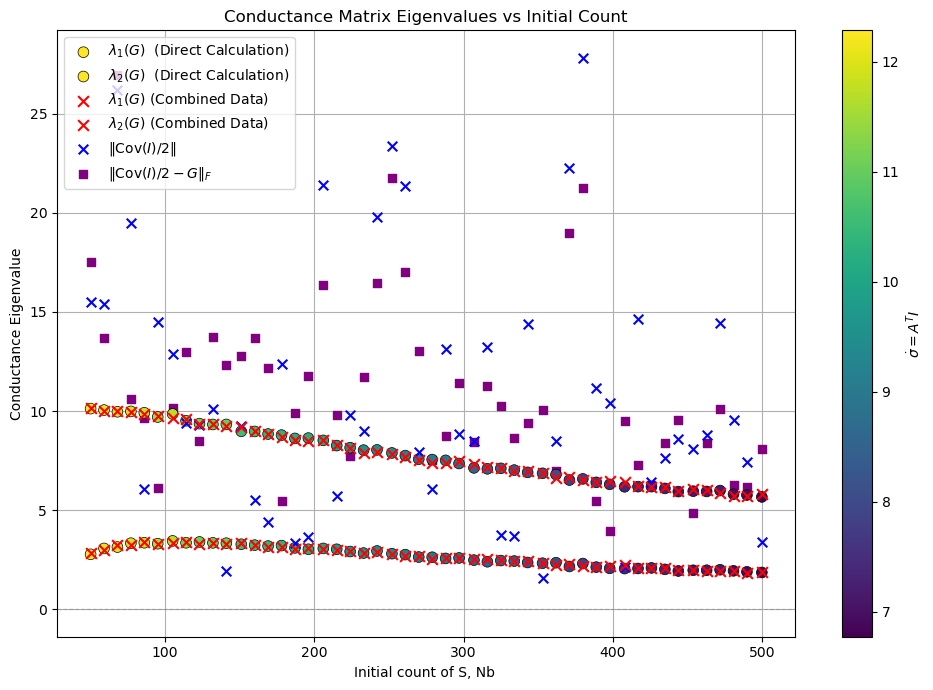

In [8]:
SIM3.plot_conductance(
        analytical_G=eigenvalues,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=True
    )